In [14]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import tensorflow as tf

print("TensorFlow installed successfully")
print("TensorFlow version:", tf.__version__)

TensorFlow installed successfully
TensorFlow version: 2.21.0


In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print("All imports loaded successfully")
print("TensorFlow version:", tf.__version__)

All imports loaded successfully
TensorFlow version: 2.21.0


In [17]:
SPLIT_DIR = r"E:\DermaAI_DiagnosticTool\outputs\splits"

train_path = os.path.join(SPLIT_DIR, "train_metadata.csv")
val_path = os.path.join(SPLIT_DIR, "val_metadata.csv")
test_path = os.path.join(SPLIT_DIR, "test_metadata.csv")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

display(train_df.head())

Train: (6985, 10)
Validation: (1481, 10)
Test: (1549, 10)


,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,lesion_type,age_filled
0,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,E:\DermaAI_DiagnosticTool\dataset_extracted\HA...,Benign keratosis like lesions,80.0
1,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,E:\DermaAI_DiagnosticTool\dataset_extracted\HA...,Benign keratosis like lesions,80.0
2,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,E:\DermaAI_DiagnosticTool\dataset_extracted\HA...,Benign keratosis like lesions,75.0
3,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,E:\DermaAI_DiagnosticTool\dataset_extracted\HA...,Benign keratosis like lesions,75.0
4,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back,E:\DermaAI_DiagnosticTool\dataset_extracted\HA...,Benign keratosis like lesions,70.0


In [18]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

print("Classes:", CLASS_NAMES)
print("Number of classes:", len(CLASS_NAMES))

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Number of classes: 7


In [19]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 6985 validated image filenames belonging to 7 classes.
Found 1481 validated image filenames belonging to 7 classes.
Found 1549 validated image filenames belonging to 7 classes.
Class indices: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [20]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image min value:", images.min())
print("Image max value:", images.max())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 7)
Image min value: -1.0
Image max value: 1.0


In [21]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array(CLASS_NAMES),
    y=train_df["dx"]
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print("Class weights:")
for class_name, index in train_generator.class_indices.items():
    print(class_name, ":", class_weights[index])

Class weights:
akiec : 4.7068733153638815
bcc : 2.9348739495798317
bkl : 1.2599206349206349
df : 10.394345238095237
mel : 1.3146997929606625
nv : 0.21258141091971514
vasc : 10.846273291925465


In [22]:
print("Available devices:")
print(tf.config.list_physical_devices())

print("\nGPU devices:")
print(tf.config.list_physical_devices("GPU"))

Available devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

GPU devices:
[]


In [23]:
def windows_to_wsl_path(path):
    return path.replace("\\", "/").replace("E:", "/mnt/e")

train_df["image_path"] = train_df["image_path"].apply(windows_to_wsl_path)
val_df["image_path"] = val_df["image_path"].apply(windows_to_wsl_path)
test_df["image_path"] = test_df["image_path"].apply(windows_to_wsl_path)

print("Sample WSL path:")
print(train_df["image_path"].iloc[0])

print("\nPath exists:")
print(os.path.exists(train_df["image_path"].iloc[0]))

Sample WSL path:
/mnt/e/DermaAI_DiagnosticTool/dataset_extracted/HAM10000_images_part_1/ISIC_0026769.jpg

Path exists:
False


In [24]:
import os
import platform
import sys

print("Python executable:")
print(sys.executable)

print("\nSystem:")
print(platform.system())

print("\n/mnt exists:", os.path.exists("/mnt"))
print("/mnt/e exists:", os.path.exists("/mnt/e"))
print("/mnt/c exists:", os.path.exists("/mnt/c"))

if os.path.exists("/mnt"):
    print("\nContents of /mnt:")
    print(os.listdir("/mnt"))

Python executable:
c:\Users\yehan\AppData\Local\Programs\Python\Python310\python.exe

System:
Windows

/mnt exists: False
/mnt/e exists: False
/mnt/c exists: False


In [25]:
SPLIT_DIR = r"E:\DermaAI_DiagnosticTool\outputs\splits"

train_path = os.path.join(SPLIT_DIR, "train_metadata.csv")
val_path = os.path.join(SPLIT_DIR, "val_metadata.csv")
test_path = os.path.join(SPLIT_DIR, "test_metadata.csv")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nSample path:")
print(train_df["image_path"].iloc[0])

print("\nPath exists:")
print(os.path.exists(train_df["image_path"].iloc[0]))

Train: (6985, 10)
Validation: (1481, 10)
Test: (1549, 10)

Sample path:
E:\DermaAI_DiagnosticTool\dataset_extracted\HAM10000_images_part_1\ISIC_0026769.jpg

Path exists:
True


In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


In [27]:
SPLIT_DIR = r"E:\DermaAI_DiagnosticTool\outputs\splits"

train_path = os.path.join(SPLIT_DIR, "train_metadata.csv")
val_path = os.path.join(SPLIT_DIR, "val_metadata.csv")
test_path = os.path.join(SPLIT_DIR, "test_metadata.csv")

train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nSample image path:")
print(train_df["image_path"].iloc[0])

print("\nPath exists:")
print(os.path.exists(train_df["image_path"].iloc[0]))

Train: (6985, 10)
Validation: (1481, 10)
Test: (1549, 10)

Sample image path:
E:\DermaAI_DiagnosticTool\dataset_extracted\HAM10000_images_part_1\ISIC_0026769.jpg

Path exists:
True


In [28]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Class indices:", train_generator.class_indices)

Found 6985 validated image filenames belonging to 7 classes.
Found 1481 validated image filenames belonging to 7 classes.
Found 1549 validated image filenames belonging to 7 classes.
Class indices: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [29]:
images, labels = next(train_generator)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image min value:", images.min())
print("Image max value:", images.max())

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16, 7)
Image min value: -0.99982077
Image max value: 1.0


In [ ]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array(CLASS_NAMES),
    y=train_df["dx"]
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print("Class weights:")
for class_name, index in train_generator.class_indices.items():
    print(class_name, ":", class_weights[index])

Class weights:
akiec : 4.7068733153638815
bcc : 2.9348739495798317
bkl : 1.2599206349206349
df : 10.394345238095237
mel : 1.3146997929606625
nv : 0.21258141091971514
vasc : 10.846273291925465


In [ ]:
MODEL_DIR = r"E:\DermaAI_DiagnosticTool\models"
os.makedirs(MODEL_DIR, exist_ok=True)

best_model_path = os.path.join(MODEL_DIR, "mobilenetv2_best_model.keras")
final_model_path = os.path.join(MODEL_DIR, "mobilenetv2_final_model.keras")

print("Model folder ready:", MODEL_DIR)
print("Best model path:", best_model_path)
print("Final model path:", final_model_path)

Model folder ready: E:\DermaAI_DiagnosticTool\models
Best model path: E:\DermaAI_DiagnosticTool\models\mobilenetv2_best_model.keras
Final model path: E:\DermaAI_DiagnosticTool\models\mobilenetv2_final_model.keras


In [ ]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output_layer = Dense(len(CLASS_NAMES), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output_layer)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,619,719 (9.99 MB)

 Trainable params: 361,735 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
callbacks = [
    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [ ]:
EPOCHS = 3

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/3
256/437 ━━━━━━━━━━━━━━━━━━━━ 48s 267ms/step - accuracy: 0.2329 - loss: 2.1060

KeyboardInterrupt: 

In [ ]:
model.save(final_model_path)

print("Final model saved to:", final_model_path)
print("Best model saved to:", best_model_path)

Final model saved to: E:\DermaAI_DiagnosticTool\models\mobilenetv2_final_model.keras
Best model saved to: E:\DermaAI_DiagnosticTool\models\mobilenetv2_best_model.keras


In [ ]:
OUTPUT_DIR = r"E:\DermaAI_DiagnosticTool\outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

history_df = pd.DataFrame(history.history)

history_path = os.path.join(OUTPUT_DIR, "mobilenetv2_initial_training_history.csv")
history_df.to_csv(history_path, index=False)

print("Training history saved to:", history_path)

display(history_df)

Training history saved to: E:\DermaAI_DiagnosticTool\outputs\mobilenetv2_initial_training_history.csv


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.296779,1.928035,0.446995,1.574514,0.0001
1,0.410880,1.636145,0.517893,1.430503,0.0001
2,0.459127,1.488140,0.550979,1.325628,0.0001


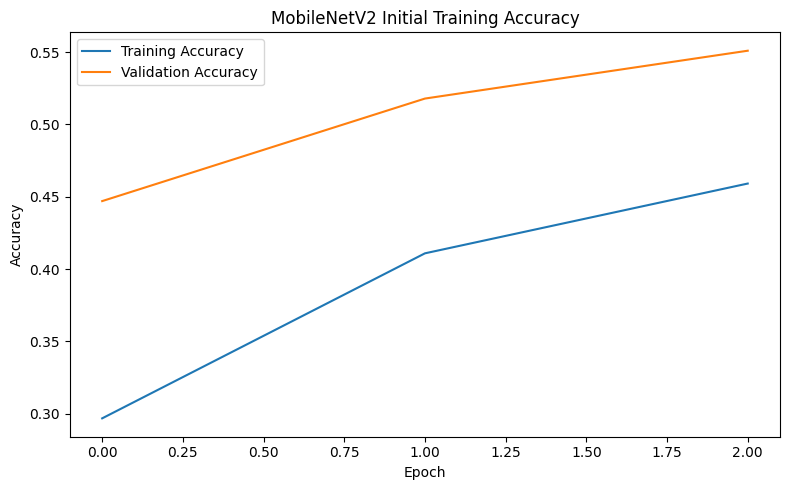

Accuracy plot saved to: E:\DermaAI_DiagnosticTool\outputs\mobilenetv2_initial_accuracy.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MobileNetV2 Initial Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()

accuracy_plot_path = os.path.join(OUTPUT_DIR, "mobilenetv2_initial_accuracy.png")
plt.savefig(accuracy_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy plot saved to:", accuracy_plot_path)

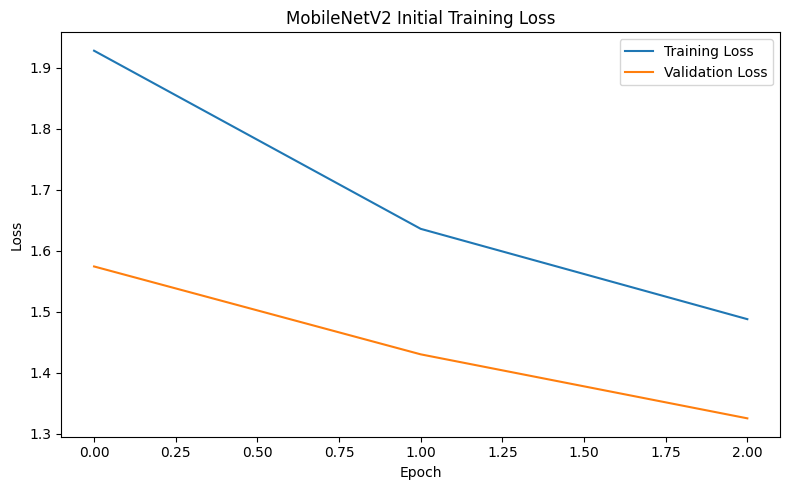

Loss plot saved to: E:\DermaAI_DiagnosticTool\outputs\mobilenetv2_initial_loss.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("MobileNetV2 Initial Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

loss_plot_path = os.path.join(OUTPUT_DIR, "mobilenetv2_initial_loss.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss plot saved to:", loss_plot_path)

## Initial MobileNetV2 Training Summary

The initial MobileNetV2 transfer learning model was trained for 3 epochs using the HAM10000 training and validation datasets. The base MobileNetV2 layers were frozen, and custom dense classification layers were added for seven class skin lesion classification. Data augmentation and class weighting were used to address image variation and class imbalance.

The model showed steady improvement across the initial training run. Validation accuracy increased from 44.70 percent in epoch 1 to 55.10 percent in epoch 3, while validation loss decreased from 1.5745 to 1.3256. This confirms that the training pipeline, image generators, class weights, model architecture and saving process are functioning correctly.

In [35]:
from tensorflow.keras.models import load_model

best_model = load_model(best_model_path)

print("Best model loaded from:", best_model_path)

Best model loaded from: E:\DermaAI_DiagnosticTool\models\mobilenetv2_best_model.keras


In [36]:
test_generator.reset()

test_loss, test_accuracy = best_model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

97/97 ━━━━━━━━━━━━━━━━━━━━ 27s 267ms/step - accuracy: 0.5152 - loss: 1.3252
Test Loss: 1.3252081871032715
Test Accuracy: 0.5151710510253906


In [37]:
test_generator.reset()

predictions = best_model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

print("Predictions shape:", predictions.shape)
print("True labels shape:", y_true.shape)

97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 165ms/step
Predictions shape: (1549, 7)


AttributeError: 'list' object has no attribute 'shape'

In [38]:
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_path = os.path.join(OUTPUT_DIR, "mobilenetv2_initial_classification_report.csv")
report_df.to_csv(report_path)

print("Classification report saved to:", report_path)

,precision,recall,f1-score,support
akiec,0.360465,0.462687,0.405229,67.000000
bcc,0.333333,0.500000,0.400000,98.000000
bkl,0.338983,0.122699,0.180180,163.000000
df,0.051724,0.692308,0.096257,13.000000
mel,0.298643,0.358696,0.325926,184.000000
nv,0.933333,0.601399,0.731470,1001.000000
vasc,0.096774,0.913043,0.175000,23.000000
accuracy,0.515171,0.515171,0.515171,0.515171
macro avg,0.344751,0.521547,0.330580,1549.000000
weighted avg,0.712839,0.515171,0.576609,1549.000000


Classification report saved to: E:\DermaAI_DiagnosticTool\outputs\mobilenetv2_initial_classification_report.csv


In [39]:
y_true = np.array(test_generator.classes)

print("Predictions shape:", predictions.shape)
print("True labels shape:", y_true.shape)

Predictions shape: (1549, 7)
True labels shape: (1549,)


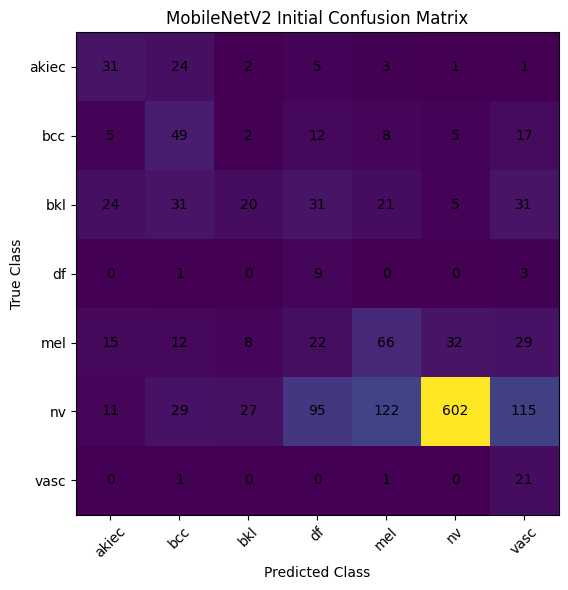

Confusion matrix saved to: E:\DermaAI_DiagnosticTool\outputs\mobilenetv2_initial_confusion_matrix.png


In [40]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("MobileNetV2 Initial Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=CLASS_NAMES,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=CLASS_NAMES
)

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()

cm_path = os.path.join(OUTPUT_DIR, "mobilenetv2_initial_confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:", cm_path)

## Initial Test Evaluation Summary

The initial MobileNetV2 model achieved a test accuracy of 51.52 percent and a weighted F1 score of 0.5766. The weighted F1 score was higher than the macro F1 score because the dataset is highly imbalanced, with the melanocytic nevi class representing the largest portion of the dataset.

The model performed strongest on the nv class, achieving an F1 score of 0.7315. However, performance on minority classes such as df and vasc remained weak. This indicates that although class weighting helped the model attend to underrepresented classes, further improvement is required through additional training, fine tuning, and more detailed evaluation using the confusion matrix.

This baseline result confirms that the image loading pipeline, preprocessing, model architecture, class weighting strategy, training process, model saving and test evaluation process are functioning correctly.

In [41]:
EPOCHS_CONTINUE = 5

history_continue = best_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_CONTINUE,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/5
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.4633 - loss: 1.4187
Epoch 1: val_accuracy improved from None to 0.60972, saving model to E:\DermaAI_DiagnosticTool\models\mobilenetv2_best_model.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 130s 293ms/step - accuracy: 0.4766 - loss: 1.4066 - val_accuracy: 0.6097 - val_loss: 1.1515 - learning_rate: 1.0000e-04
Epoch 2/5
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.4964 - loss: 1.3880
Epoch 2: val_accuracy did not improve from 0.60972
437/437 ━━━━━━━━━━━━━━━━━━━━ 131s 300ms/step - accuracy: 0.5055 - loss: 1.3338 - val_accuracy: 0.5800 - val_loss: 1.1699 - learning_rate: 1.0000e-04
Epoch 3/5
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.5121 - loss: 1.2776
Epoch 3: val_accuracy did not improve from 0.60972
437/437 ━━━━━━━━━━━━━━━━━━━━ 134s 306ms/step - accuracy: 0.5145 - loss: 1.2693 - val_accuracy: 0.5922 - val_loss: 1.1058 - learning_rate: 1.0000e-04
Epoch 4/5
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accu

In [42]:
best_model = load_model(best_model_path)

print("Updated best model loaded from:", best_model_path)

Updated best model loaded from: E:\DermaAI_DiagnosticTool\models\mobilenetv2_best_model.keras


In [43]:
test_generator.reset()

test_loss, test_accuracy = best_model.evaluate(test_generator)

print("Updated Test Loss:", test_loss)
print("Updated Test Accuracy:", test_accuracy)

97/97 ━━━━━━━━━━━━━━━━━━━━ 19s 177ms/step - accuracy: 0.6172 - loss: 1.0297
Updated Test Loss: 1.0297106504440308
Updated Test Accuracy: 0.617172360420227


In [44]:
test_generator.reset()

predictions = best_model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = np.array(test_generator.classes)

print("Predictions shape:", predictions.shape)
print("True labels shape:", y_true.shape)

97/97 ━━━━━━━━━━━━━━━━━━━━ 20s 196ms/step
Predictions shape: (1549, 7)
True labels shape: (1549,)


In [45]:
updated_report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

updated_report_df = pd.DataFrame(updated_report).transpose()

display(updated_report_df)

updated_report_path = os.path.join(
    OUTPUT_DIR,
    "mobilenetv2_continued_classification_report.csv"
)

updated_report_df.to_csv(updated_report_path)

print("Updated classification report saved to:", updated_report_path)

,precision,recall,f1-score,support
akiec,0.511111,0.343284,0.410714,67.000000
bcc,0.473214,0.540816,0.504762,98.000000
bkl,0.340909,0.368098,0.353982,163.000000
df,0.140000,0.538462,0.222222,13.000000
mel,0.315245,0.663043,0.427320,184.000000
nv,0.942577,0.672328,0.784840,1001.000000
vasc,0.276923,0.782609,0.409091,23.000000
accuracy,0.617172,0.617172,0.617172,0.617172
macro avg,0.428569,0.558377,0.444705,1549.000000
weighted avg,0.739769,0.617172,0.652830,1549.000000


Updated classification report saved to: E:\DermaAI_DiagnosticTool\outputs\mobilenetv2_continued_classification_report.csv


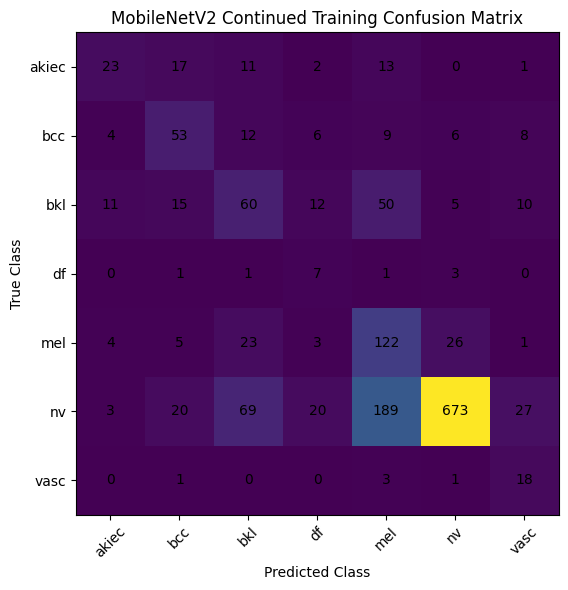

Updated confusion matrix saved to: E:\DermaAI_DiagnosticTool\outputs\mobilenetv2_continued_confusion_matrix.png


In [46]:
updated_cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(updated_cm)
plt.title("MobileNetV2 Continued Training Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=CLASS_NAMES,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=CLASS_NAMES
)

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        plt.text(j, i, updated_cm[i, j], ha="center", va="center")

plt.tight_layout()

updated_cm_path = os.path.join(
    OUTPUT_DIR,
    "mobilenetv2_continued_confusion_matrix.png"
)

plt.savefig(updated_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Updated confusion matrix saved to:", updated_cm_path)

## Continued Training Test Evaluation Summary

After continuing training for an additional 5 epochs, the MobileNetV2 model showed improved performance. The updated best model achieved a test accuracy of 61.72 percent and a test loss of 1.0297. This is a clear improvement compared with the initial baseline test accuracy of 51.52 percent.

The confusion matrix shows that the model performs strongly on the dominant nv class and shows improved recognition across several minority classes. However, some misclassifications remain between visually similar lesion categories such as bkl, mel and nv. This reflects the complexity of skin lesion classification and the class imbalance present in the HAM10000 dataset.

The continued training result confirms that the frozen MobileNetV2 feature extractor and custom classification layers are learning meaningful visual patterns. A controlled fine tuning stage will be used next to improve the model by allowing selected deeper MobileNetV2 layers to adapt to the skin lesion dataset.

In [47]:
# Load the latest best model
fine_tune_model = load_model(best_model_path)

# Freeze all layers first
for layer in fine_tune_model.layers:
    layer.trainable = False

# Unfreeze the last 30 layers, except BatchNormalization layers
for layer in fine_tune_model.layers[-30:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

# Compile with a much lower learning rate for fine tuning
fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine tuning model compiled.")

trainable_count = sum([layer.trainable for layer in fine_tune_model.layers])
print("Number of trainable layers:", trainable_count)

Fine tuning model compiled.
Number of trainable layers: 22


In [48]:
fine_tuned_best_model_path = os.path.join(MODEL_DIR, "mobilenetv2_finetuned_best_model.keras")
fine_tuned_final_model_path = os.path.join(MODEL_DIR, "mobilenetv2_finetuned_final_model.keras")

fine_tune_callbacks = [
    ModelCheckpoint(
        filepath=fine_tuned_best_model_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [49]:
FINE_TUNE_EPOCHS = 3

fine_tune_history = fine_tune_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights,
    callbacks=fine_tune_callbacks
)

Epoch 1/3
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.5614 - loss: 1.1170
Epoch 1: val_accuracy improved from None to 0.62255, saving model to E:\DermaAI_DiagnosticTool\models\mobilenetv2_finetuned_best_model.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 167s 367ms/step - accuracy: 0.5486 - loss: 1.1683 - val_accuracy: 0.6226 - val_loss: 1.0544 - learning_rate: 1.0000e-05
Epoch 2/3
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.5408 - loss: 1.1193
Epoch 2: val_accuracy improved from 0.62255 to 0.65024, saving model to E:\DermaAI_DiagnosticTool\models\mobilenetv2_finetuned_best_model.keras
437/437 ━━━━━━━━━━━━━━━━━━━━ 132s 301ms/step - accuracy: 0.5578 - loss: 1.1327 - val_accuracy: 0.6502 - val_loss: 1.0067 - learning_rate: 1.0000e-05
Epoch 3/3
437/437 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.5649 - loss: 1.1010
Epoch 3: val_accuracy did not improve from 0.65024
437/437 ━━━━━━━━━━━━━━━━━━━━ 147s 336ms/step - accuracy: 0.5737 - loss: 1.1102 - val_accuracy: 0.5807 - v

In [50]:
fine_tuned_best_model = load_model(fine_tuned_best_model_path)

test_generator.reset()

fine_tuned_test_loss, fine_tuned_test_accuracy = fine_tuned_best_model.evaluate(test_generator)

print("Fine tuned Test Loss:", fine_tuned_test_loss)
print("Fine tuned Test Accuracy:", fine_tuned_test_accuracy)

97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 161ms/step - accuracy: 0.6423 - loss: 0.9994
Fine tuned Test Loss: 0.9994146823883057
Fine tuned Test Accuracy: 0.642349898815155


In [51]:
test_generator.reset()

fine_tuned_predictions = fine_tuned_best_model.predict(test_generator)

fine_tuned_y_pred = np.argmax(fine_tuned_predictions, axis=1)
fine_tuned_y_true = np.array(test_generator.classes)

fine_tuned_report = classification_report(
    fine_tuned_y_true,
    fine_tuned_y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

fine_tuned_report_df = pd.DataFrame(fine_tuned_report).transpose()

display(fine_tuned_report_df)

fine_tuned_report_path = os.path.join(
    OUTPUT_DIR,
    "mobilenetv2_finetuned_classification_report.csv"
)

fine_tuned_report_df.to_csv(fine_tuned_report_path)

print("Fine tuned classification report saved to:", fine_tuned_report_path)

97/97 ━━━━━━━━━━━━━━━━━━━━ 19s 185ms/step


,precision,recall,f1-score,support
akiec,0.373984,0.686567,0.484211,67.00000
bcc,0.573034,0.520408,0.545455,98.00000
bkl,0.340000,0.417178,0.374656,163.00000
df,0.082090,0.846154,0.149660,13.00000
mel,0.402010,0.434783,0.417755,184.00000
nv,0.945098,0.722278,0.818800,1001.00000
vasc,0.410256,0.695652,0.516129,23.00000
accuracy,0.642350,0.642350,0.642350,0.64235
macro avg,0.446639,0.617574,0.472381,1549.00000
weighted avg,0.753486,0.642350,0.682548,1549.00000


Fine tuned classification report saved to: E:\DermaAI_DiagnosticTool\outputs\mobilenetv2_finetuned_classification_report.csv


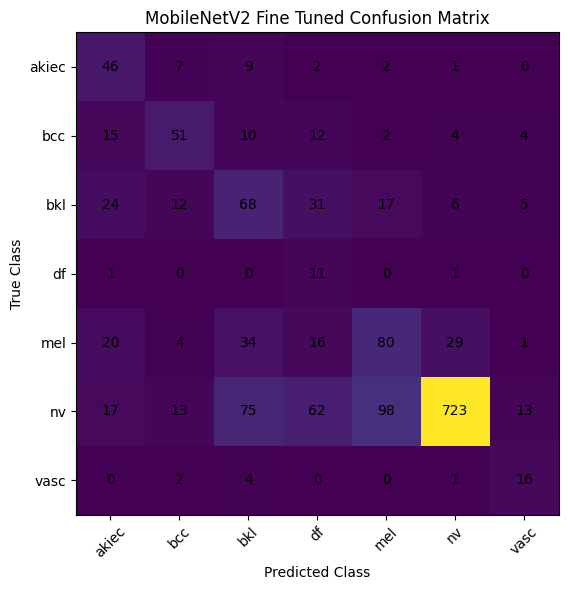

Fine tuned confusion matrix saved to: E:\DermaAI_DiagnosticTool\outputs\mobilenetv2_finetuned_confusion_matrix.png


In [52]:
fine_tuned_cm = confusion_matrix(fine_tuned_y_true, fine_tuned_y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(fine_tuned_cm)
plt.title("MobileNetV2 Fine Tuned Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=CLASS_NAMES,
    rotation=45
)

plt.yticks(
    ticks=np.arange(len(CLASS_NAMES)),
    labels=CLASS_NAMES
)

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        plt.text(j, i, fine_tuned_cm[i, j], ha="center", va="center")

plt.tight_layout()

fine_tuned_cm_path = os.path.join(
    OUTPUT_DIR,
    "mobilenetv2_finetuned_confusion_matrix.png"
)

plt.savefig(fine_tuned_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Fine tuned confusion matrix saved to:", fine_tuned_cm_path)

In [53]:
fine_tuned_best_model.save(fine_tuned_final_model_path)

print("Fine tuned final model saved to:", fine_tuned_final_model_path)

Fine tuned final model saved to: E:\DermaAI_DiagnosticTool\models\mobilenetv2_finetuned_final_model.keras


## Fine Tuned MobileNetV2 Evaluation Summary

The fine tuned MobileNetV2 model achieved the best performance among the training stages completed so far. The test accuracy improved to 64.23 percent, compared with 51.52 percent from the initial baseline model and 61.72 percent from the continued frozen model.

The weighted F1 score improved to 0.6825, showing stronger overall performance across the test set. The macro F1 score remained lower at 0.4724, which reflects the continued difficulty of classifying minority classes within the imbalanced HAM10000 dataset.

The model performed strongest on the nv class, achieving an F1 score of 0.8188. The bcc, akiec and vasc classes also showed meaningful improvement. However, confusion remained between visually similar lesion categories such as bkl, mel and nv. The df class showed high recall but low precision, indicating that the model identified many true df cases but also over predicted this class.

Based on the evaluation results, the fine tuned MobileNetV2 model was selected as the best current model for the system. This model will be used for the next stage of the project, where Grad CAM explainability will be implemented to visually highlight image regions that influenced the prediction.

In [54]:
comparison_data = {
    "Model Stage": [
        "Initial MobileNetV2",
        "Continued Training MobileNetV2",
        "Fine Tuned MobileNetV2"
    ],
    "Test Accuracy": [
        0.5152,
        0.6172,
        0.6423
    ],
    "Test Loss": [
        1.3252,
        1.0297,
        0.9994
    ],
    "Weighted F1 Score": [
        0.5766,
        None,
        0.6825
    ],
    "Macro F1 Score": [
        0.3306,
        None,
        0.4724
    ]
}

comparison_df = pd.DataFrame(comparison_data)

display(comparison_df)

comparison_path = os.path.join(
    OUTPUT_DIR,
    "mobilenetv2_model_comparison.csv"
)

comparison_df.to_csv(comparison_path, index=False)

print("Model comparison saved to:", comparison_path)

,Model Stage,Test Accuracy,Test Loss,Weighted F1 Score,Macro F1 Score
0,Initial MobileNetV2,0.5152,1.3252,0.5766,0.3306
1,Continued Training MobileNetV2,0.6172,1.0297,NaN,NaN
2,Fine Tuned MobileNetV2,0.6423,0.9994,0.6825,0.4724


Model comparison saved to: E:\DermaAI_DiagnosticTool\outputs\mobilenetv2_model_comparison.csv
